# LayoutLMv3 Demo: Base vs. Fine-Tuned Pipeline Comparison

This notebook demonstrates the difference between the standard LayoutLMv3 base model and your custom fine-tuned model on a single invoice PDF.

### Document Target
- **File**: `invoice_sample.pdf`

## Step 0: Shared Setup & Configurations
First, we import the necessary libraries and define the shared functions for PDF conversion and inference processing.

In [4]:
import os
import sys
import json
import torch
import fitz  # PyMuPDF
import numpy as np
import torch.nn.functional as nnf
import matplotlib.pyplot as plt
from PIL import Image
from transformers import LayoutLMv3Processor, LayoutLMv3TokenizerFast, LayoutLMv3ImageProcessor

# --- ROBUST PATH RESOLUTION ---
CWD = os.getcwd()

# 1. Find the project subdirectory (where 'src' and 'inputs' live)
if os.path.exists(os.path.join(CWD, 'Finetuning')):
    PROJECT_SUBDIR = os.path.join(CWD, 'Finetuning')
else:
    PROJECT_SUBDIR = CWD

# 2. Append 'src' to system path for trainer and utils
sys.path.append(os.path.join(PROJECT_SUBDIR, 'src'))
from trainer import ModelModule
from utils import dataSetFormat, plot_img

# 3. Configure paths relative to where they are found
LABEL_CONFIG_PATH = os.path.join(PROJECT_SUBDIR, "inputs", "label_config.json")
MODEL_WEIGHTS = os.path.join(PROJECT_SUBDIR, "src", "model.bin")
BASE_MODEL_NAME = "microsoft/layoutlmv3-base"

# 4. Find the PDF
if os.path.exists(os.path.join(CWD, "invoice_sample.pdf")):
    PDF_PATH = os.path.join(CWD, "invoice_sample.pdf")
else:
    PDF_PATH = os.path.join("..", "invoice_sample.pdf")

# Load Labels
with open(LABEL_CONFIG_PATH, "r") as f:
    config = json.load(f)
id2label = {int(v): k for k, v in config["label2id"].items()}
num_labels = len(id2label)

# Initialize Shared Processor
feature_extractor = LayoutLMv3ImageProcessor(apply_ocr=False)
tokenizer = LayoutLMv3TokenizerFast.from_pretrained(BASE_MODEL_NAME, ignore_mismatched_sizes=True)
processor = LayoutLMv3Processor(tokenizer=tokenizer, image_processor=feature_extractor)

print(f"Target PDF: {PDF_PATH}")
print(f"Project Subdir: {PROJECT_SUBDIR}")
print(f"Labels loaded: {len(id2label)}")

Target PDF: d:\Internship\Invoice Intelligence Document\Demo-LayoutLMv3\invoice_CPI007529709.pdf
Project Subdir: d:\Internship\Invoice Intelligence Document\Demo-LayoutLMv3\Finetuning
Labels loaded: 49


In [5]:
def convert_pdf_to_images(pdf_path, dpi=300):
    """Converts a PDF file to a list of PIL Images (Optimized)."""
    doc = fitz.open(pdf_path)
    zoom = dpi / 72
    mat = fitz.Matrix(zoom, zoom)
    images = []
    for page in doc:
        pix = page.get_pixmap(matrix=mat)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(img)
    doc.close()
    return images

def run_prediction(image, model, processor, id2label):
    """Core LayoutLMv3 prediction logic."""
    test_dict, w_scale, h_scale = dataSetFormat(image)
    encoding = processor(image, test_dict["tokens"], boxes=test_dict["bboxes"], 
                         max_length=512, stride=128, padding="max_length", truncation=True, 
                         return_overflowing_tokens=True, return_offsets_mapping=True, return_tensors="pt")
    
    final_predictions = {}
    for i in range(len(encoding.input_ids)):
        with torch.no_grad():
            inputs = {k: encoding[k][i].unsqueeze(0) for k in ["input_ids", "attention_mask", "bbox", "pixel_values"]}
            logits, _ = model(**inputs)
            probs = nnf.softmax(logits.squeeze(0), dim=-1).numpy()
            labels = logits.argmax(dim=-1).squeeze().tolist()
            for idx, word_id in enumerate(encoding.word_ids(i)):
                if word_id is None or encoding["offset_mapping"][i][idx][0] != 0: continue
                label_id, prob = labels[idx], probs[idx][labels[idx]]
                if word_id not in final_predictions or prob > final_predictions[word_id]["prob"]:
                    final_predictions[word_id] = {"label_id": label_id, "prob": prob, "box": encoding["bbox"][i][idx].tolist(), "text": test_dict["tokens"][word_id]}
    
    results = [{"label": id2label.get(p["label_id"], "O"), "confidence": p["prob"], "text": p["text"], "box": p["box"]} 
               for word_id, p in sorted(final_predictions.items()) if id2label.get(p["label_id"], "O") != "O"]
    return results, w_scale, h_scale

---
## Pipeline A: Base Model Inference (Untrained Baseline)
This section demonstrate how the original LayoutLMv3 base model performs on your specific dataset. (Usually inaccurate before fine-tuning)

Initializing Base Model...


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 5154.98it/s]
LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Processing Page 1 with Base Model...
[2026/04/14 15:42:18] ppocr WARNING: Since the angle classifier is not initialized, the angle classifier will not be uesd during the forward process
[2026/04/14 15:42:19] ppocr DEBUG: dt_boxes num : 129, elapse : 0.21078920364379883
[2026/04/14 15:42:20] ppocr DEBUG: rec_res num  : 129, elapse : 1.7469401359558105
Probability score : tensor([[[0.0142, 0.0236, 0.0243,  ..., 0.0194, 0.0223, 0.0213],
         [0.0148, 0.0199, 0.0276,  ..., 0.0227, 0.0239, 0.0253],
         [0.0161, 0.0195, 0.0254,  ..., 0.0227, 0.0247, 0.0268],
         ...,
         [0.0135, 0.0201, 0.0185,  ..., 0.0254, 0.0226, 0.0237],
         [0.0147, 0.0179, 0.0200,  ..., 0.0251, 0.0264, 0.0172],
         [0.0142, 0.0236, 0.0243,  ..., 0.0194, 0.0223, 0.0213]]])
top_p, top_class  tensor([[[0.0333],
         [0.0322],
         [0.0277],
         [0.0310],
         [0.0272],
         [0.0318],
         [0.0322],
         [0.0334],
         [0.0280],
         [0.0350],
         [0.0

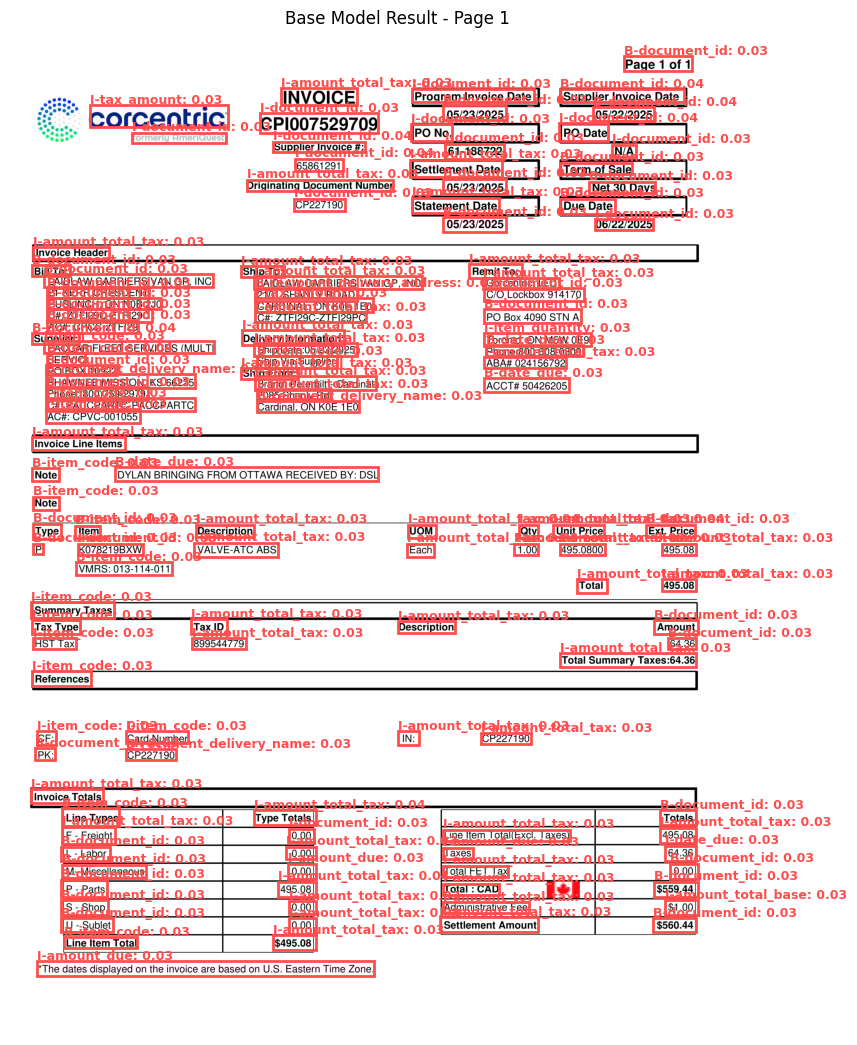

In [14]:
print("Initializing Base Model...")
base_model = ModelModule(num_labels)
# Using default weights from microsoft/layoutlmv3-base
base_model.eval()
for i, page_img in enumerate(pages):
    print(f"Processing Page {i+1} with Base Model...")
    res, w, h = run_prediction(page_img, base_model, processor, id2label)
    plt.figure(figsize=(10, 15))
    plt.imshow(page_img)
    ax = plt.gca()
    
    for r in res:
        x1, y1 = r['box'][0]*w/1000, r['box'][1]*h/1000
        wb, hb = (r['box'][2]-r['box'][0])*w/1000, (r['box'][3]-r['box'][1])*h/1000
        
        # Color: Light Red (#ff4d4d)
        light_red = '#ff4d4d'
        
        # Bounding Box
        ax.add_patch(plt.Rectangle((x1, y1), wb, hb, linewidth=2, 
                                   edgecolor=light_red, facecolor='none'))
        
        # Label: Light Red text, no background box
        ax.text(x1, y1 - 5, f"{r['label']}: {r['confidence']:.2f}", 
                fontsize=9, color=light_red, fontweight='bold')
        
    plt.title(f"Base Model Result - Page {i+1}")
    plt.axis('off')
    plt.show()


---
## Pipeline B: Fine-Tuned Model Inference (Production)
This section loads your custom weights from `model.bin`. This is the **actual extraction pipeline** optimized for your invoices.

Initializing Fine-Tuned Model...


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 6107.93it/s]
LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Processing Page 1 with Fine-Tuned Model...
[2026/04/14 15:36:49] ppocr WARNING: Since the angle classifier is not initialized, the angle classifier will not be uesd during the forward process
[2026/04/14 15:36:49] ppocr DEBUG: dt_boxes num : 129, elapse : 0.2192211151123047
[2026/04/14 15:36:51] ppocr DEBUG: rec_res num  : 129, elapse : 1.972339391708374
Probability score : tensor([[[2.1565e-01, 9.2901e-03, 1.1951e-02,  ..., 1.4262e-02,
          1.9305e-02, 1.2162e-02],
         [9.9652e-01, 2.5412e-05, 3.9476e-05,  ..., 1.0284e-04,
          1.0713e-04, 5.0320e-05],
         [9.9650e-01, 2.5639e-05, 4.0415e-05,  ..., 1.0404e-04,
          1.0748e-04, 5.0494e-05],
         ...,
         [1.7215e-01, 2.0914e-03, 2.7923e-03,  ..., 3.0979e-02,
          3.4796e-03, 3.9635e-03],
         [9.9640e-01, 2.5402e-05, 3.9033e-05,  ..., 9.4891e-05,
          1.1021e-04, 4.8507e-05],
         [2.1241e-01, 9.3443e-03, 1.2059e-02,  ..., 1.4285e-02,
          1.9448e-02, 1.2224e-02]]])
top_p, top_cl

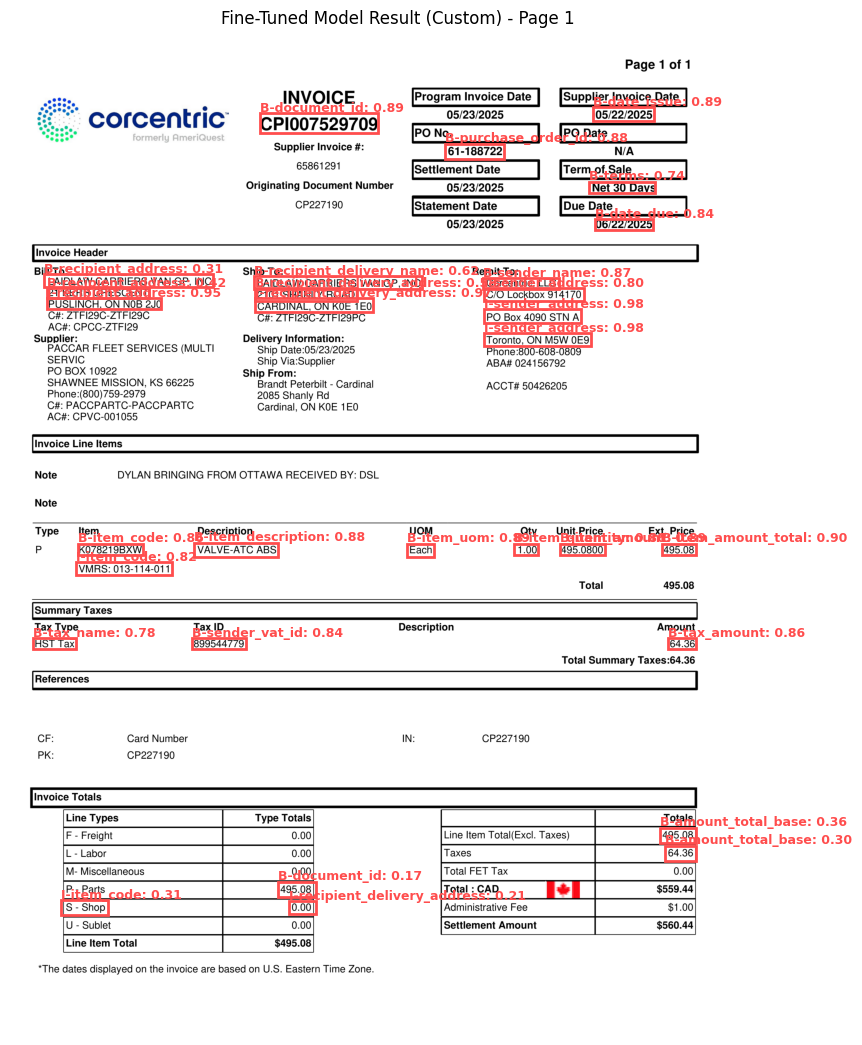

In [ ]:
print("Initializing Fine-Tuned Model...")
ft_model = ModelModule(num_labels)
ft_model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location="cpu"))
ft_model.eval()
for i, page_img in enumerate(pages):
    print(f"Processing Page {i+1} with Fine-Tuned Model...")
    res, w, h = run_prediction(page_img, ft_model, processor, id2label)
    plt.figure(figsize=(10, 15))
    plt.imshow(page_img)
    ax = plt.gca()
    
    for r in res:
        x1, y1 = r['box'][0]*w/1000, r['box'][1]*h/1000
        wb, hb = (r['box'][2]-r['box'][0])*w/1000, (r['box'][3]-r['box'][1])*h/1000
        
        # Color: Light Red (#ff4d4d)
        light_red = '#ff4d4d'
        
        # Bounding Box
        ax.add_patch(plt.Rectangle((x1, y1), wb, hb, linewidth=2, 
                                   edgecolor=light_red, facecolor='none'))
        
        # Label: Light Red text, no background box (shifted slightly up with -5)
        ax.text(x1, y1 - 5, f"{r['label']}: {r['confidence']:.2f}", 
                fontsize=9, color=light_red, fontweight='bold')
                
    plt.title(f"Fine-Tuned Model Result (Custom) - Page {i+1}")
    plt.axis('off')
    plt.show()